## Library and Load Data

In [16]:
import os
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

In [6]:
# paths
DATA_RAW  = Path("../../../data/raw")
DATA_EXT  = Path("../../../data/external")
DATA_PROC = Path("../../../data/processed")
CACHE_DIR = Path("../../../data/cache")

os.makedirs(DATA_EXT,  exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# project CRS — California Albers, distance-preserving
PROJECT_CRS = "EPSG:3310"

In [7]:
# enable caching so re-runs don't re-download
ox.settings.cache_folder = str(CACHE_DIR)
ox.settings.use_cache    = True
ox.settings.log_console  = True

### 1. Load LA County boundary

In [ ]:
la = gpd.read_file(DATA_RAW / "la_county.geojson")

# dissolve to single polygon in case of multipart geometry
la_polygon = la.dissolve().geometry.iloc[0]

print(f"Boundary CRS : {la.crs}")
print(f"Geometry type: {la_polygon.geom_type}")

Boundary CRS : EPSG:4326
Geometry type: MultiPolygon


### 2. Download road network
Filtered to evacuation-relevant road types only — pulling all roads would result in tens of millions of edges.

In [10]:
# tertiary included for last-mile neighborhood access during evacuations
G = ox.graph_from_polygon(
    la_polygon,
    network_type="drive",
    custom_filter='["highway"~"motorway|trunk|primary|secondary|tertiary"]'
)

print(f"Nodes : {len(G.nodes):,}")
print(f"Edges : {len(G.edges):,}")

Nodes : 26,716
Edges : 61,375


### 3. Project to EPSG:3310

In [11]:
G_proj = ox.project_graph(G, to_crs=PROJECT_CRS)

nodes, edges = ox.graph_to_gdfs(G_proj)
print(f"Edges CRS: {edges.crs}")

Edges CRS: EPSG:3310


### 4. Edge type breakdown

In [12]:
# highway column can be a list — normalize to string first
edges["highway_type"] = edges["highway"].apply(
    lambda x: x[0] if isinstance(x, list) else x
)

edges["highway_type"].value_counts()

highway_type
tertiary          19550
secondary         16761
primary           14102
motorway_link      3678
motorway           3133
primary_link       1521
trunk               993
secondary_link      974
tertiary_link       438
trunk_link          225
Name: count, dtype: int64

### 5. Save outputs

In [ ]:
# GraphML — used for Dijkstra / A* routing in models step
ox.save_graphml(G_proj, DATA_EXT / "road_network.graphml")

# GeoJSON edges — used for spatial joins and visualization
edges_save = edges.drop(columns=["highway_type"], errors="ignore")  # drop temp column
edges_save.to_file(DATA_EXT / "escape_routes_roads.geojson", driver="GeoJSON")

print("Saved:")
print(f"  {DATA_EXT / 'road_network.graphml'}")
print(f"  {DATA_EXT / 'escape_routes_roads.geojson'}")

Saved:
  ../../data/external/road_network.graphml
  ../../data/external/escape_routes_roads.geojson


### 6. CRS alignment check
Confirm all processed layers match before moving to spatial joins.

In [ ]:
layers = {
    "road edges"   : edges,
    "svi_tracts"   : gpd.read_file(DATA_PROC / "svi_tracts.geojson").to_crs(PROJECT_CRS),
    "all_stations" : gpd.read_file(DATA_PROC / "all_stations.geojson").to_crs(PROJECT_CRS),
    "Fire_Hydrants": gpd.read_file(DATA_PROC / "Fire_Hydrants.geojson").to_crs(PROJECT_CRS),
    "hospitals"    : gpd.read_file(DATA_PROC / "hospitals.geojson").to_crs(PROJECT_CRS),
}

for name, gdf in layers.items():
    status = "OK" if str(gdf.crs) == PROJECT_CRS else "MISMATCH"
    print(f"{status}  {name:20s}  {gdf.crs}")

OK  road edges            EPSG:3310
OK  svi_tracts            EPSG:3310
OK  all_stations          EPSG:3310
OK  Fire_Hydrants         EPSG:3310
OK  hospitals             EPSG:3310


### 7. Quick visualization

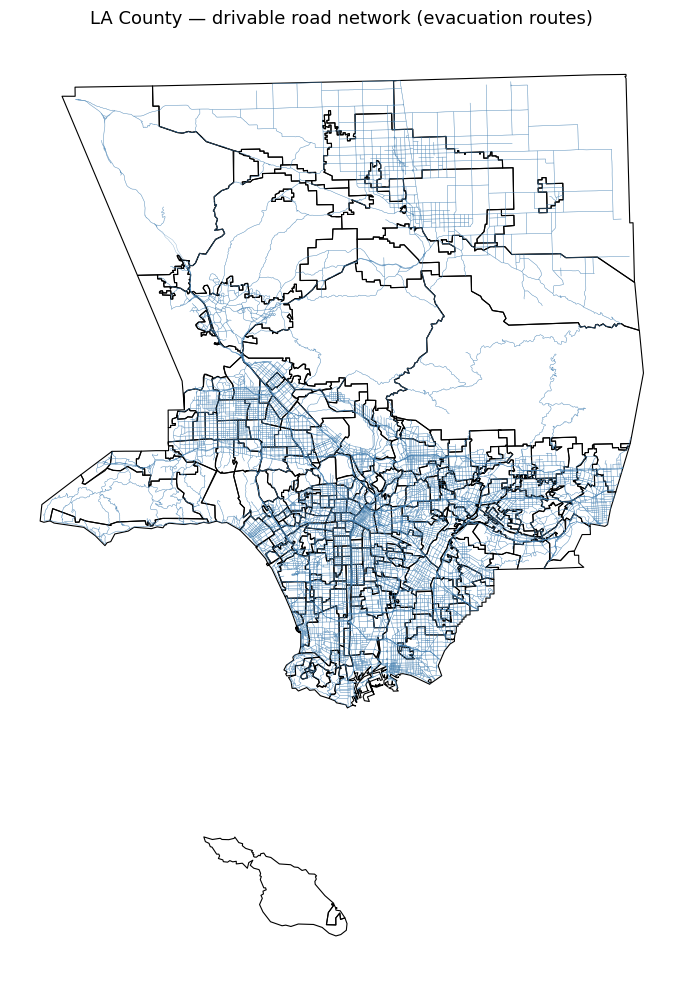

In [17]:
la_proj = la.to_crs(PROJECT_CRS)

fig, ax = plt.subplots(figsize=(12, 10))
la_proj.plot(ax=ax, color="none", edgecolor="black", linewidth=0.8)
edges.plot(ax=ax, linewidth=0.3, color="steelblue", alpha=0.6)

ax.set_title("LA County — drivable road network (evacuation routes)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()